 Sequences shape: (49976, 24, 4)
Epoch 1/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - loss: 0.0327
Epoch 2/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - loss: 0.0012
Epoch 3/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - loss: 9.4035e-04
Epoch 4/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - loss: 8.8534e-04
Epoch 5/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 41s 41ms/step - loss: 8.6378e-04
Epoch 6/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 42s 43ms/step - loss: 8.5562e-04
Epoch 7/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - loss: 8.5023e-04
Epoch 8/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 41s 42ms/step - loss: 8.4546e-04
Epoch 9/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 31s 40ms/step - loss: 8.4097e-04
Epoch 10/10
781/781 ━━━━━━━━━━━━━━━━━━━━ 32s 42ms/step - loss: 8.3648e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step


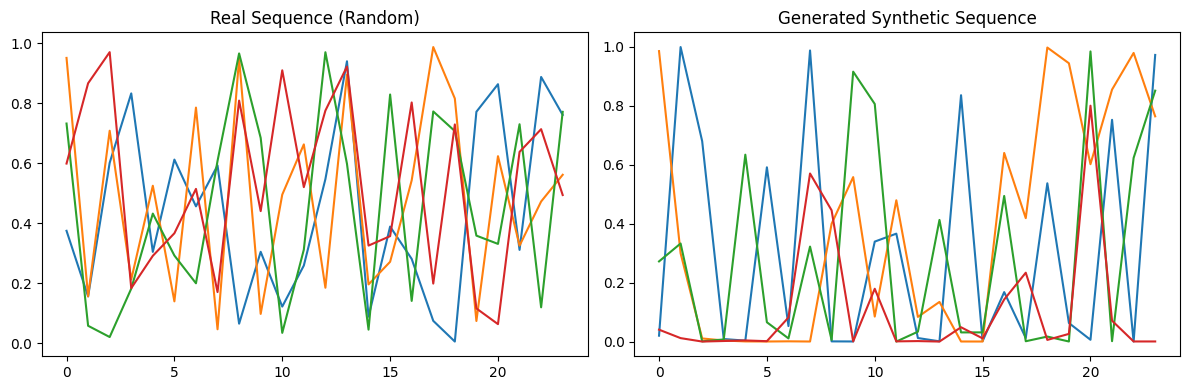

In [2]:
# Install libraries if needed
# !pip install numpy pandas matplotlib tensorflow scikit-learn

# 1. Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import MinMaxScaler

# 2. Create synthetic random time series data
# Let's simulate some fake data: 50000 time points, 4 features
np.random.seed(42)  # for reproducibility
data = np.random.rand(50000, 4)  # random values between 0 and 1

# Convert to a DataFrame
columns = ['Feature1', 'Feature2', 'Feature3', 'Feature4']
df = pd.DataFrame(data, columns=columns)

# 3. Normalize the features (optional, but good for training)
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# 4. Create time sequences (24 steps each)
sequence_length = 24
sequences = [scaled_data[i:i+sequence_length] for i in range(len(scaled_data) - sequence_length)]
sequences = np.array(sequences)

print(" Sequences shape:", sequences.shape)  # e.g., (49976, 24, 4)

# 5. Build a simple LSTM Generator
def build_generator(seq_len, feature_dim):
    model = tf.keras.Sequential([
        layers.Input(shape=(seq_len, feature_dim)),
        layers.LSTM(100, return_sequences=True),
        layers.TimeDistributed(layers.Dense(feature_dim, activation='sigmoid'))
    ])
    return model

seq_len = sequences.shape[1]
feature_dim = sequences.shape[2]
generator = build_generator(seq_len, feature_dim)

# 6. Compile and Train the Generator
generator.compile(optimizer='adam', loss='mse')
generator.fit(sequences, sequences, epochs=10, batch_size=64)

# 7. Generate Synthetic Data
noise = tf.random.normal((1, seq_len, feature_dim))
synthetic = generator.predict(noise)[0]

# 8. Visualize Real vs Synthetic Data
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(sequences[0])
plt.title("Real Sequence (Random)")

plt.subplot(1, 2, 2)
plt.plot(synthetic)
plt.title("Generated Synthetic Sequence")

plt.tight_layout()
plt.show()


